In [1]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import optuna
import seaborn as sns
from catboost import CatBoostRegressor
from scipy.stats import pearsonr
import pandas as pd
from catboost import Pool
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [7]:
df_catboost = pd.read_csv("/path_to_the_file/df_nocvd_cohort_train_test.csv")
    
train = df_catboost[df_catboost['Center'] == 0].copy() # Cheadle Center 
test = df_catboost[df_catboost['Center'].isin([1, 2])].copy() # Reading and Newcastle centers


X = train.drop(columns=['eid','age_imaging_derived','Center']).values
y = train['age_imaging_derived'].values

X_test=test.drop(columns=['eid','age_imaging_derived','Center']).values
y_test = test['age_imaging_derived'].values


# Identify columns for model training:
sex_column_index = 0  # Categorical column index for 'sex'
continuous_columns_indices = list(range(1, X.shape[1])) # Indices of continuous columns
all_columns_names= train.columns.drop(['eid','age_imaging_derived','Center']).tolist() #Names of all columns used for training

print(f'train size:{X.shape}, test size:{X_test.shape}')

train size:(10018, 57), test size:(3676, 57)


In [8]:
# 10-fold cross validation using the optimal hyperparameters
Best_hyperparameters_cross_val={'learning_rate': 0.05673164300143394, 
                                  'depth': 4, 
                                  'l2_leaf_reg': 20, 
                                  'boosting_type': 'Plain', 
                                  'bootstrap_type': 'Bernoulli', 
                                  'subsample': 0.5010897645895341,
                                  'cat_features': [0], #Categorical column index for 'sex'
                                  'loss_function': 'RMSE',
                                  'eval_metric': "MAE",
                                  'metric_period' : 5,
                                  'task_type': "GPU",
                                  'devices': '1',
                                  'silent': False,
                                  'random_seed': 97,
                                  'early_stopping_rounds' : 100,
                                  'use_best_model': True}


# Evaluation metrics    
val_r2_scores = []
val_r_scores = []
val_mae_scores = []

# Store all training data prediction for age-bias estimation 
all_val_labels=[] 
all_val_preds=[]


kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_idx=0

for train_index, val_index in kf.split(X):
    fold_idx += 1

    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    scaler = StandardScaler()
    
    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()
    
    X_train_scaled[:, continuous_columns_indices] = scaler.fit_transform(X_train[:, continuous_columns_indices])
    X_val_scaled[:, continuous_columns_indices] = scaler.transform(X_val[:, continuous_columns_indices])


    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=all_columns_names)
    X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=all_columns_names)

    X_train_scaled_df['Sex'] = X_train_scaled_df['Sex'].astype('int')
    X_val_scaled_df['Sex'] = X_val_scaled_df['Sex'].astype('int')

    train_pool = Pool(X_train_scaled_df, y_train, cat_features=[sex_column_index])
    val_pool = Pool(X_val_scaled_df, y_val, cat_features=[sex_column_index])

    model = CatBoostRegressor(**Best_hyperparameters_cross_val)
    model.fit(train_pool, eval_set=val_pool,verbose=0)
    
    val_pred = model.predict(val_pool)
    
    all_val_labels.extend(y_val)
    all_val_preds.extend(val_pred)
    
    val_mae = mean_absolute_error(y_val, val_pred)
    val_r, _ = pearsonr(y_val, val_pred)
    val_r2 = r2_score(y_val, val_pred)

    val_r_scores.append(val_r)
    val_r2_scores.append(val_r2)
    val_mae_scores.append(val_mae)


# Print average 10-old cross validation results
print(f"Average val_MAE: {np.mean(val_mae_scores):.2f}+- {np.std(val_mae_scores):.2f}")
print(f"Average val_r: {np.mean(val_r_scores):.2f}+- {np.std(val_r_scores):.2f}")
print(f"Average val_R^2: {np.mean(val_r2_scores):.2f}+- {np.std(val_r2_scores):.2f}")


Average val_MAE: 3.88+- 0.06
Average val_r: 0.75+- 0.01
Average val_R^2: 0.57+- 0.01


In [9]:
# Retraining the model with otimal hyperparameters and the full training data
Best_hyperparameters_full_train={'learning_rate': 0.05673164300143394, 
                                  'depth': 4, 
                                  'l2_leaf_reg': 20, 
                                  'boosting_type': 'Plain', 
                                  'bootstrap_type': 'Bernoulli', 
                                  'subsample': 0.5010897645895341,
                                  'cat_features': [0], 
                                  'loss_function': 'RMSE',
                                  'task_type': "GPU",
                                  'devices': '1',
                                  'silent': True,
                                  'random_seed': 97
                                  }


model = CatBoostRegressor(**Best_hyperparameters_full_train)

X_train_scaled=X.copy()
X_test_scaled=X_test.copy()

scaler = StandardScaler()

X_train_scaled[:, continuous_columns_indices] = scaler.fit_transform(X[:, continuous_columns_indices])  
X_test_scaled[:, continuous_columns_indices] = scaler.transform(X_test[:, continuous_columns_indices])

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=all_columns_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=all_columns_names)

X_train_scaled_df['Sex'] = X_train_scaled_df['Sex'].astype('int')
X_test_scaled_df['Sex'] = X_test_scaled_df['Sex'].astype('int')

train_pool = Pool(X_train_scaled_df, y, cat_features=[sex_column_index])
test_pool = Pool(X_test_scaled_df, y_test, cat_features=[sex_column_index])

model.fit(train_pool,verbose=0)

train_pred = model.predict(train_pool)

train_r2 = r2_score(y, train_pred)
train_pearson_corr, _ = pearsonr(y, train_pred)
train_mae = mean_absolute_error(y, train_pred)

test_pred = model.predict(test_pool)
test_r2 = r2_score(y_test, test_pred)
test_pearson_corr, _ = pearsonr(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)


print('Final Best Model for all train data:')
print(f"Train_MAE: {train_mae:.2f}")
print(f"Train_r: {train_pearson_corr:.2f}")
print(f"Train_R^2: {train_r2:.2f}")


print('Final Best Model for all test data:')
print(f"test_MAE: {test_mae:.2f}")
print(f"test_r: {test_pearson_corr:.2f}")
print(f"test_R^2: {test_r2:.2f}")

Final Best Model for all train data:
Train_MAE: 3.42
Train_r: 0.82
Train_R^2: 0.66
Final Best Model for all test data:
test_MAE: 3.88
test_r: 0.75
test_R^2: 0.56


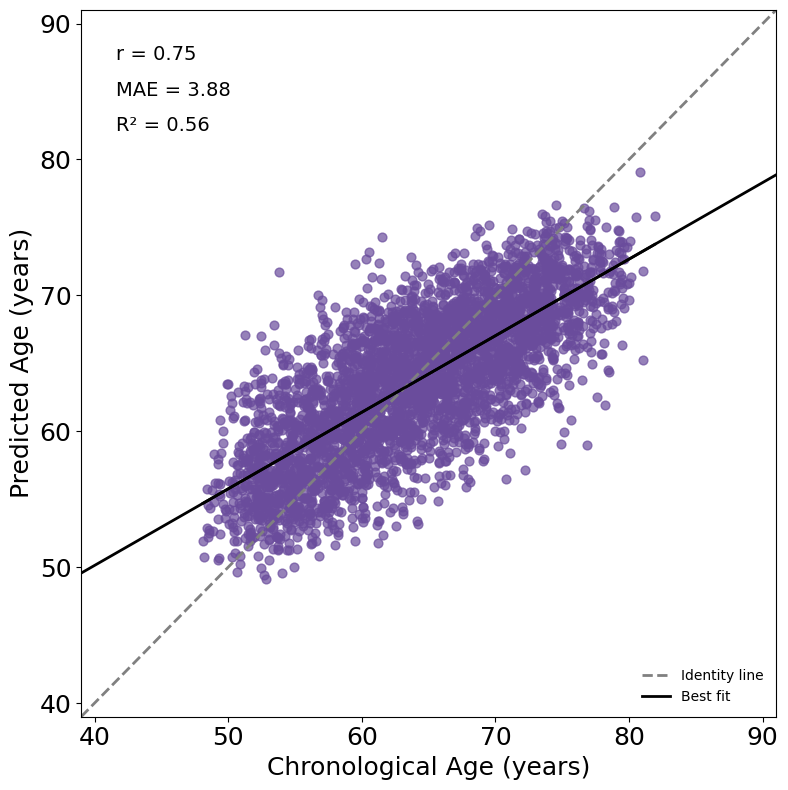

In [10]:
# Plot predicted age vs. chronological age for the test set
# - Scatter points show individual predictions
# - Dashed gray line: identity line (perfect prediction)
# - Solid black line: linear regression fit (best fit)
# - Displayed statistics: Pearson correlation (r), MAE, and R²

ca_test = y_test  
ba_test = test_pred 


mae = mean_absolute_error(ca_test, ba_test)
r2 = r2_score(ca_test, ba_test)
r, p_value = pearsonr(ca_test, ba_test)

plt.figure(figsize=(8, 8))


sns.regplot(
    x=ca_test,
    y=ba_test,
    scatter_kws={'s': 40, 'alpha': 0.7,'color': '#6A4C9C'},
    line_kws={'color': 'black', 'lw': 2}, ci=None
)

plt.plot(
    [39, 91],
    [39, 91],
    linestyle='--',
    color='gray',
    linewidth=2,
    label='Identity line'
)

slope, intercept = np.polyfit(ca_test, ba_test, 1)
fit_line_x = np.array([39, 91])
fit_line_y = slope * fit_line_x + intercept
plt.plot(fit_line_x, fit_line_y, color='black', lw=2, label='Best fit')


plt.text(0.05, 0.95, f"r = {r:.2f}", transform=plt.gca().transAxes, fontsize=14, va='top')
plt.text(0.05, 0.90, f"MAE = {mae:.2f}", transform=plt.gca().transAxes, fontsize=14, va='top')
plt.text(0.05, 0.85, f"R² = {r2:.2f}", transform=plt.gca().transAxes, fontsize=14, va='top')

plt.xlabel('Chronological Age (years)', fontsize=18)
plt.ylabel('Predicted Age (years)', fontsize=18)
plt.xlim(39, 91)
plt.ylim(39, 91)

plt.legend(frameon=False)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tight_layout()

plt.show()


In [11]:
def Age_bias_caluculation(all_preds,all_labels):
    """
    Calculate the age prediction bias using a linear model.

    Parameters:
    -----------
    all_preds : array-like
        Predicted ages from the model (training data predictions from 10-fold cross validation).
    all_labels : array-like
        True chronological ages corresponding to predictions.

    Returns:
    --------
    b : array
        Coefficients [intercept, slope] from a GLM fit of prediction errors 
        
    """
    
    gap = all_preds - all_labels
    glm_model = sm.GLM(gap, sm.add_constant(all_labels), family=sm.families.Gaussian())
    glm_results = glm_model.fit()
    b = glm_results.params
    
    return b

all_train_preds = np.array(all_val_preds)
all_train_labels = np.array(all_val_labels)

b= Age_bias_caluculation(all_train_preds,all_train_labels)
print(f'Intercept:{b[0]:.2f}, Slope:{b[1]:.2f}')

Intercept:26.92, Slope:-0.43


In [12]:
def Age_bias_correction(ca, ba, b):
    """
    ca : Chronological age (age_imaging_derived)
    ba : Predicted  cardiovascular age
    b  : Regression coefficients [intercept, slope]

    Returns
    -------
    ba_corrected : Bias-corrected cardiovascular age
    age_gap_corr : Bias-corrected age gap (CardioAG)
    """

    # Predicted age bias term: α + β * ca
    yfit = sm.add_constant(ca) @ b

    # Bias-corrected ba
    ba_corrected = ba - yfit

    # Bias-corrected age gap
    age_gap_corr = ba_corrected - ca

    return ba_corrected, age_gap_corr


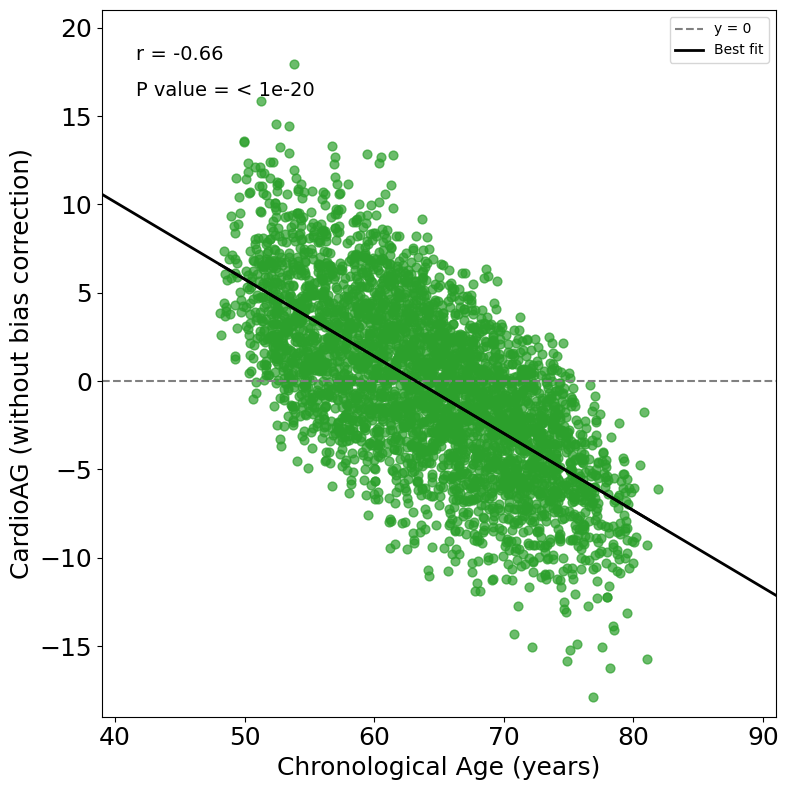

In [16]:
# Plot the age gap (Predicted Age - Chronological Age, CardioAG) before bias correction
# - Scatter points show the age gap for each individual in the test set
# - Solid black line: linear regression fit of the age gap vs. chronological age
# - Dashed gray line: y = 0 (no prediction bias)
# - Displayed metrics: Pearson correlation coefficient (r) and P-value
# This plot helps visualize whether prediction errors systematically vary with age


age_gap = ba_test - ca_test


r, p_value = pearsonr(ca_test, age_gap)
if p_value < 1e-20:
    p_value='< 1e-20'
else:
    p_value= f'{p_value:.2f}'
    

plt.figure(figsize=(8, 8))

sns.regplot(x=ca_test, y=age_gap, scatter_kws={'s': 40, 'alpha': 0.7, 'color': '#2ca02c'},
            line_kws={'color': 'black', 'lw': 2}, ci=None, color='royalblue')


plt.axhline(y=0, color='gray', linestyle='--', label='y = 0')


slope, intercept = np.polyfit(ca_test, age_gap, 1)
fit_line_x = np.array([39, 91])
fit_line_y = slope * fit_line_x + intercept
plt.plot(fit_line_x, fit_line_y, color='black', lw=2, label='Best fit')


plt.text(0.05, 0.95, f"r = {r:.2f}", transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')
plt.text(0.05, 0.90, f"P value = {p_value}", transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')


plt.xlabel('Chronological Age (years)', fontsize=18)
plt.ylabel('CardioAG (without bias correction)', fontsize=18)


plt.xlim(39, 91)
plt.ylim(-19, 21)
plt.tick_params(axis='both', which='major', labelsize=18)


plt.legend()
plt.tight_layout()

plt.show()

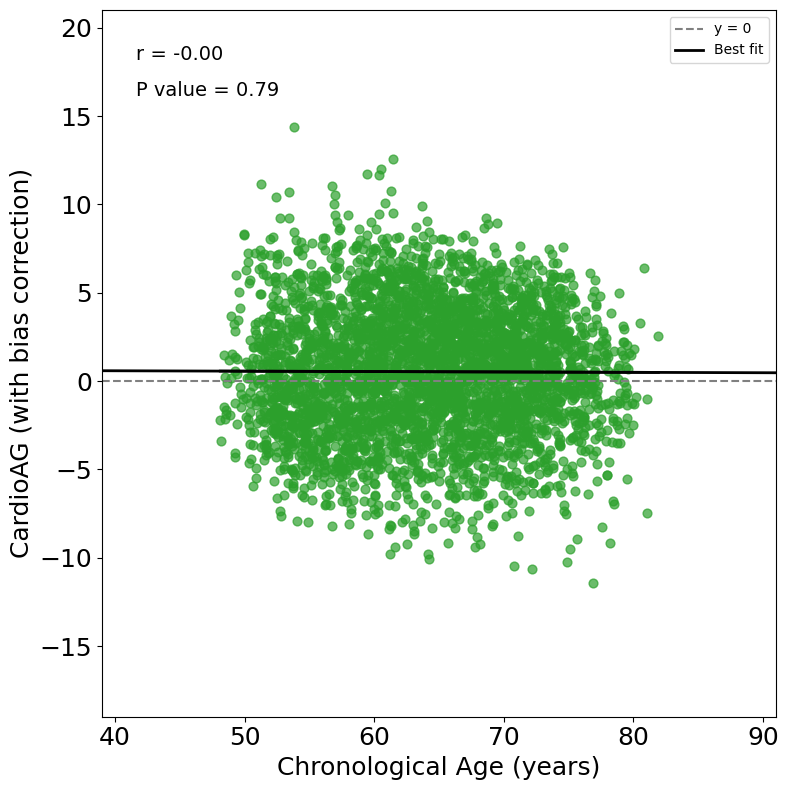

In [15]:
# Plot the age gap (Predicted Age - Chronological Age) after bias correction
# - Scatter points show the corrected age gap (CardioAG) for each individual in the test set
# - Solid black line: linear regression fit of the corrected age gap vs. chronological age
# - Dashed gray line: y = 0 (no prediction bias)
# - Displayed metrics: Pearson correlation coefficient (r) and P-value
# This plot allows visualization of whether prediction errors remain age-dependent
# after applying bias correction, demonstrating the effectiveness of the correction.

ba_corr, age_gap_corr = Age_bias_correction(ca=ca_test,ba=ba_test,b=b)

r, p_value = pearsonr(ca_test, age_gap_corr)

plt.figure(figsize=(8, 8))

sns.regplot(x=ca_test, y=age_gap_corr, scatter_kws={'s': 40, 'alpha': 0.7, 'color': '#2ca02c'},
            line_kws={'color': 'black', 'lw': 2}, ci=None, color='royalblue')

plt.axhline(y=0, color='gray', linestyle='--', label='y = 0')

slope, intercept = np.polyfit(ca_test, age_gap_corr, 1)
fit_line_x = np.array([39, 91])
fit_line_y = slope * fit_line_x + intercept
plt.plot(fit_line_x, fit_line_y, color='black', lw=2, label='Best fit')

plt.text(0.05, 0.95, f"r = {r:.2f}", transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')
plt.text(0.05, 0.90, f"P value = {p_value:.2f}", transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')

plt.xlabel('Chronological Age (years)', fontsize=18)
plt.ylabel('CardioAG (with bias correction)', fontsize=18)

plt.xlim(39, 91)
plt.ylim(-19, 21)
plt.tick_params(axis='both', which='major', labelsize=18)

plt.legend()
plt.tight_layout()

plt.show()